# 21 - Depth vs Breadth, done properly

**Section:** More on Data | **Prereqs:** `Cross Validation/DataLoader.ipynb` | **Next:** `More on Data/FeatureAugmentation.ipynb`

The third pass at this experiment, and the first with all the machinery in
place: a data-generating function, a model factory, a train/test split, mini-batch
DataLoaders, and both accuracies reported. Depths go up to **80 layers**, which
is where the interesting failure lives.

**The result to expect:** accuracy rises with width, then *collapses* with depth.
A plain 80-layer ReLU stack barely trains at all - gradients have to survive 80
multiplications on the way back, and they either vanish or explode. Deep networks
only became trainable with the tricks in the later sections: careful
initialisation (`Weight Initialization/`), batch normalisation
(`Metaparameters/BatchNorm.ipynb`) and residual connections
(`Transfer Learning/TF_ResNet-18.ipynb`).

**Also here:** counting trainable parameters with
`sum(p.numel() for p in model.parameters() if p.requires_grad)` - the standard
one-liner for 'how big is this model?'.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib.pyplot as plt

In [ ]:
# Data factory: three Gaussian clusters -> tensors -> train/test split ->
# TensorDatasets -> DataLoaders, all returned in one dict.
# Bundling the pipeline in a function is what makes the sweep below repeatable:
# every model sees exactly the same data.

# a function that creates data

def createSomeData(nPerClust):

  A = [ 1, 1 ]
  B = [ 5, 1 ]
  C = [ 4, 4 ]

  # generate data
  a = [ A[0]+np.random.randn(nPerClust) , A[1]+np.random.randn(nPerClust) ]
  b = [ B[0]+np.random.randn(nPerClust) , B[1]+np.random.randn(nPerClust) ]
  c = [ C[0]+np.random.randn(nPerClust) , C[1]+np.random.randn(nPerClust) ]

  # true labels
  labels_np = np.hstack(( np.zeros((nPerClust)),
                          np.ones( (nPerClust)),
                        1+np.ones( (nPerClust))  ))

  # concatanate into a matrix, then convert to a pytorch tensor
  data_np = np.hstack((a,b,c)).T

  # NEW: put all outputs into a dictionary
  output = {}
  output['data'] = torch.tensor(data_np).float()
  output['labels'] = torch.tensor(labels_np).long() # note: "long" format (integers) for labels

  # use scikitlearn to split the data
  train_data,test_data, train_labels,test_labels = train_test_split(output['data'], output['labels'], train_size=.9)

  # then convert them into PyTorch Datasets (note: already converted to tensors)
  train_data = TensorDataset(train_data,train_labels)
  test_data  = TensorDataset(test_data,test_labels)

  # finally, translate into dataloader objects
  batchsize  = 8
  output['train_data'] = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
  output['test_data']  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

  return output

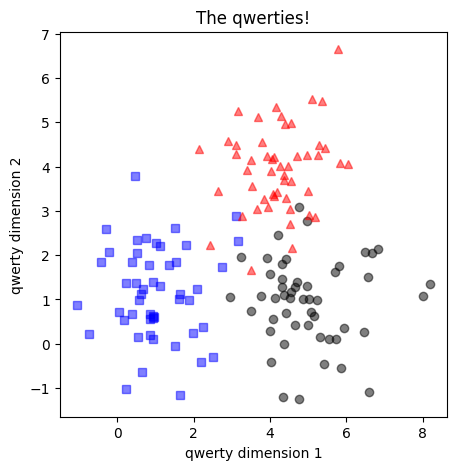

In [12]:
# The three clusters. Two overlap slightly, so perfect accuracy is not possible
# and the ceiling is around 90-95%.
theData = createSomeData(50)

data = theData['data']
labels = theData['labels']

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs',alpha=.5)
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko',alpha=.5)
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'r^',alpha=.5)
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2');

In [34]:
# Model factory: depth and width as arguments.
# The class is defined INSIDE the function, which is unusual but harmless - it
# just guarantees a fresh class object per call. Defining it at module level and
# instantiating would be the ordinary way.
# Data is really small

def create_model(nLayers, nNodes):

  class Model(nn.Module):
    def __init__(self, n_layers: int, n_nodes: int):
        super().__init__()

        self.input_layer = nn.Linear(2, n_nodes)

        self.hidden_layers = nn.ModuleList(
            [nn.Linear(n_nodes, n_nodes) for _ in range(n_layers)]
        )

        self.output_layer = nn.Linear(n_nodes, 3)

    def forward(self, x):
        x = F.relu(self.input_layer(x))

        for layer in self.hidden_layers:
            x = F.relu(layer(x))

        return self.output_layer(x)

  model = Model(nLayers,nNodes)

  return model

In [93]:
# The standard training function, parameterised by architecture.
def train_model(nLayers, nNodes):
  model = create_model(nLayers, nNodes)

  lr = 0.1
  lossFunc = nn.CrossEntropyLoss()
  epochs = 50

  optimizer = torch.optim.SGD(model.parameters(),lr=lr)

  test_acc = []
  train_acc = []
  losses = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in theData['train_data']:

      yhat = model(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100*torch.mean( (torch.argmax(yhat,dim=1) == y ).float()))

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    if epoch % 10 == 0 or epoch == epochs - 1 :
      print(f"Layers {nLayers}, Nodes {nNodes} | Epoch {epoch} | loss : {losses[epoch]}")

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(theData['test_data']))
      preds = model(X)
      test_acc.append((100*torch.mean( (torch.argmax(preds,dim=1) == Y ).float())))

  print()
  return test_acc, train_acc, losses

In [95]:
# One shallow-and-wide model as a baseline: 1 hidden layer, 100 units.
test_acc, train_acc, losses  = train_model(1,100)

Layers 1, Nodes 100 | Epoch 0 | loss : 0.7600805023685098
Layers 1, Nodes 100 | Epoch 10 | loss : 0.16433665889780968
Layers 1, Nodes 100 | Epoch 20 | loss : 0.09794111354858615
Layers 1, Nodes 100 | Epoch 30 | loss : 0.11580270525882952
Layers 1, Nodes 100 | Epoch 40 | loss : 0.1092005049213185
Layers 1, Nodes 100 | Epoch 49 | loss : 0.11168568988796324



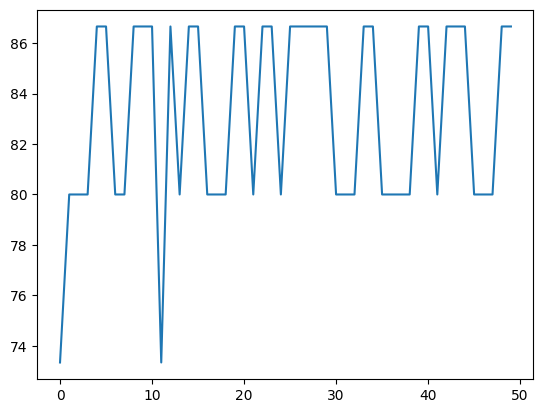

In [96]:
# Test accuracy over epochs for the baseline.
plt.plot(test_acc);

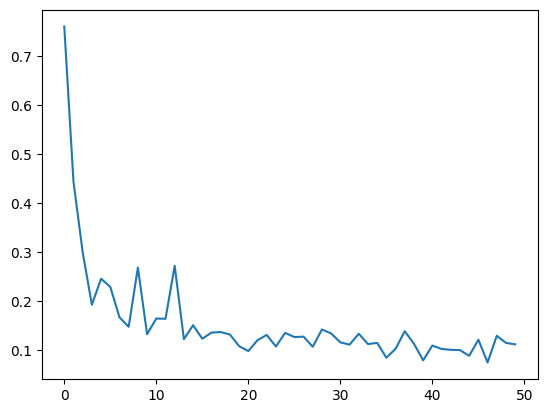

In [97]:
# Its loss curve.
plt.plot(losses);

In [98]:
# The opposite extreme: 20 layers of 4 units. Narrow AND deep - the hardest
# combination to train.
model= create_model(20,4)

In [99]:
# Counting trainable parameters. p.numel() is the element count of one tensor;
# requires_grad filters out anything frozen. This is the standard way to
# report model size.
np.sum([p.numel() for p in model.parameters() if p.requires_grad])

np.int64(427)

###Parameteric Experiment



In [100]:
# The sweep grid: depths 1, 10, 20, 80 crossed with widths 50...500.
# 80 layers is included specifically to show the failure.
layers = [1,10,20,80]
nodes = np.arange(50,550,50)

In [101]:
# Results tensor: (depth, width, [train_acc, test_acc]).
results = torch.zeros(len(layers), len(nodes), 2)
results.shape

torch.Size([4, 10, 2])

In [102]:
# The sweep. This is the slowest cell in the section - 40 models, some of them
# very deep.
for i in range(len(layers)):
  for j in range(len(nodes)):
    test_acc, train_acc, losses = train_model(layers[i],nodes[j])

    results[i,j,0] = train_acc[-1].item()
    results[i,j,1] = test_acc[-1].item()

Layers 1, Nodes 50 | Epoch 0 | loss : 0.7988307941704988
Layers 1, Nodes 50 | Epoch 10 | loss : 0.13320447143632919
Layers 1, Nodes 50 | Epoch 20 | loss : 0.11641043447889388
Layers 1, Nodes 50 | Epoch 30 | loss : 0.1239545737626031
Layers 1, Nodes 50 | Epoch 40 | loss : 0.1353271763509838
Layers 1, Nodes 50 | Epoch 49 | loss : 0.1006713966053212

Layers 1, Nodes 100 | Epoch 0 | loss : 0.7351947613060474
Layers 1, Nodes 100 | Epoch 10 | loss : 0.14353417261736467
Layers 1, Nodes 100 | Epoch 20 | loss : 0.11287822254234925
Layers 1, Nodes 100 | Epoch 30 | loss : 0.13222802529344335
Layers 1, Nodes 100 | Epoch 40 | loss : 0.10224706088774838
Layers 1, Nodes 100 | Epoch 49 | loss : 0.10470346520014573

Layers 1, Nodes 150 | Epoch 0 | loss : 0.9552751816809177
Layers 1, Nodes 150 | Epoch 10 | loss : 0.1473535560653545
Layers 1, Nodes 150 | Epoch 20 | loss : 0.13492372570908628
Layers 1, Nodes 150 | Epoch 30 | loss : 0.09728416863254097
Layers 1, Nodes 150 | Epoch 40 | loss : 0.098617069343

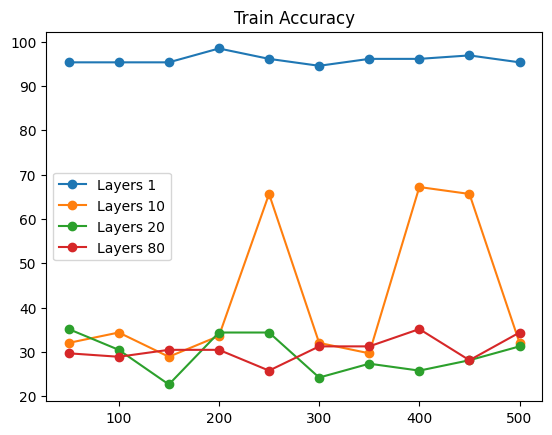

In [112]:
# Final TRAIN accuracy vs width, one line per depth.
# The 1- and 10-layer lines look healthy; the 80-layer line sits near 33%,
# which is chance on 3 classes. Depth alone does not buy capacity.
for i in range(len(layers)):
  plt.plot(nodes,results[i,:,0],'o-', label=f'Layers {layers[i]}')


plt.legend()
plt.title("Train Accuracy");

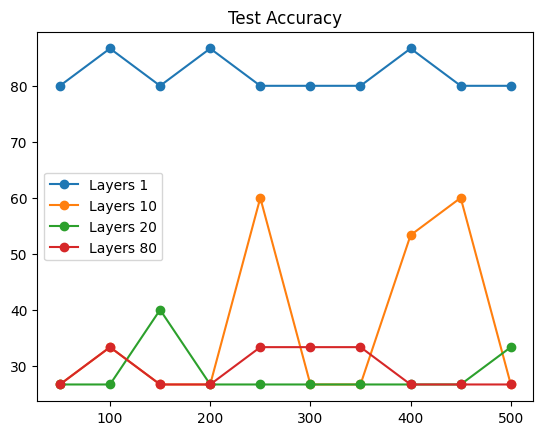

In [113]:
# Final TEST accuracy - the same story.
# Conclusion: past a certain depth a plain feedforward stack stops training,
# because gradients vanish on the way back. Everything in Weight Initialization/,
# BatchNorm and residual connections exists to fix this.
for i in range(len(layers)):
  plt.plot(nodes,results[i,:,1],'o-', label=f'Layers {layers[i]}')


plt.legend()
plt.title("Test Accuracy");